In [ ]:
# Assignment 2: Data Quality Assessment & Preprocessing
#**Student:** Fadak Alqassab  
#**Topic:** E-commerce Sales Data Cleaning and PCA Analysis

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA



In [ ]:
# Set visualization style
sns.set(style="whitegrid")

# Load the dataset
df = pd.read_csv('messy_ecommerce_sales_data.csv')


# Task 1: Identify and Fix Data Quality Issues


# 1. Fix column names (remove leading/trailing spaces)
df.columns = df.columns.str.strip()

# 2. Handle duplicates
df = df.drop_duplicates()

# 3. Standardize formats (converting messy strings to numeric/datetime)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# 4. Correct inconsistent calculations in 'Total'
# Recalculate where values are missing or obviously wrong
df['Total_Calc'] = df['Quantity'] * df['Price']
df['Total'] = df['Total'].fillna(df['Total_Calc'])

In [4]:
#Task 2: Missing Value Strategy

# Strategy: Median for numeric (robust to outliers), Mode for categorical
num_cols = ['Quantity', 'Price', 'Total']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
df['Category'] = df['Category'].fillna(df['Category'].mode()[0])

# Fill missing dates with the median date
df['Order_Date'] = df['Order_Date'].fillna(df['Order_Date'].median())

In [5]:

# Task 3: Detect and Handle Outliers using IQR


def handle_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter out outliers
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Applying outlier removal to Price and Total
df_clean = handle_outliers_iqr(df, 'Price')
df_clean = handle_outliers_iqr(df_clean, 'Total')

In [6]:

# Task 4: Normalize Numerical Features


features = ['Quantity', 'Price', 'Total']
df_subset = df_clean[features].reset_index(drop=True)

# 1. Min-Max Scaling (rescale to 0-1)
scaler_minmax = MinMaxScaler()
df_minmax = pd.DataFrame(scaler_minmax.fit_transform(df_subset), 
                         columns=[f"{f}_minmax" for f in features])

# 2. Z-score Standardization (mean=0, std=1)
scaler_zscore = StandardScaler()
df_zscore = pd.DataFrame(scaler_zscore.fit_transform(df_subset), 
                         columns=[f"{f}_zscore" for f in features])

# Combine results
df_final = pd.concat([df_clean.reset_index(drop=True), df_minmax, df_zscore], axis=1)

Processing Complete. Files generated: cleaned_ecommerce_data.csv, pca_plot.png, scree_plot.png


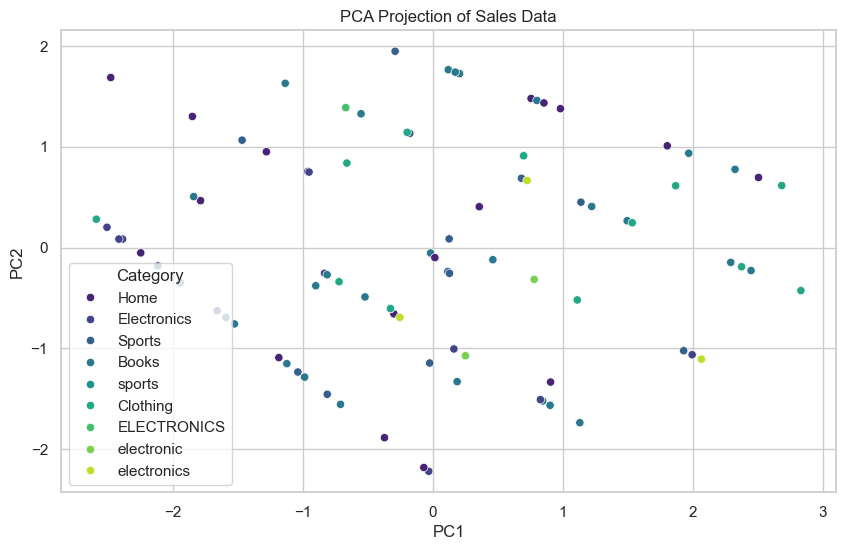

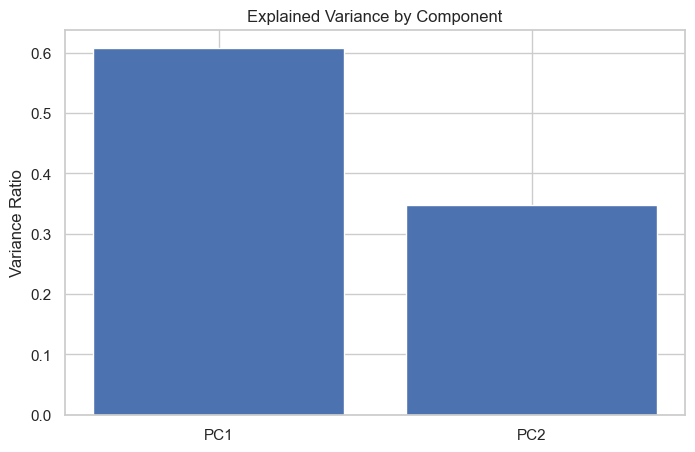

In [7]:

# Task 5: Apply PCA and Interpret


pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_zscore)

df_final['PC1'] = pca_result[:, 0]
df_final['PC2'] = pca_result[:, 1]

# Visualization: PCA Scatter Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_final, x='PC1', y='PC2', hue='Category', palette='viridis')
plt.title('PCA Projection of Sales Data')
plt.savefig('pca_plot.png')

# Visualization: Scree Plot (Explained Variance)
plt.figure(figsize=(8, 5))
plt.bar(['PC1', 'PC2'], pca.explained_variance_ratio_)
plt.title('Explained Variance by Component')
plt.ylabel('Variance Ratio')
plt.savefig('scree_plot.png')

# Save the final cleaned dataset
df_final.to_csv('cleaned_ecommerce_data.csv', index=False)

print("Processing Complete. Files generated: cleaned_ecommerce_data.csv, pca_plot.png, scree_plot.png")